# Week 10: K-means and silhouette score

This notebook explores unsupervised clustering on both project datasets: Wisconsin breast-cancer measurements and Brazil cancer-registry records. It is designed as the complete Week 10 Milestone 2 analysis.

The known outcome is excluded from clustering and is used afterward only to interpret whether discovered groups differ in diagnosis/outcome rate.

## Milestone 2 questions

- How does k-means behave on each dataset?
- What value of k is supported by inertia and silhouette score?
- How sensitive are the clusters to scaling and feature representation?
- Are the final clusters stable across random initializations?
- Do the unsupervised groups differ in the known outcome?

These address the clarifier's depth expectations: show selection, explain behavior, test sensitivity, and interpret meaningful or unexpected results.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

from src.load_data import load_wisconsin, load_brazil

RANDOM_STATE = 42
BRAZIL_SAMPLE_SIZE = 100_000
K_VALUES = range(2, 9)
FIGURE_DIR = Path("outputs/figures/milestone2")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load and inspect both datasets

The project loaders are used rather than reading files directly. Brazil is sampled reproducibly because repeated k-means tuning on 1.7 million rows is unnecessarily expensive for exploratory analysis. The sample size, seed, and full-data prevalence are reported so this computational choice is transparent.

In [2]:
wisconsin_df, wisconsin_target = load_wisconsin()
brazil_full_df, brazil_target = load_brazil(sample_size=None, random_state=RANDOM_STATE)
brazil_full_prevalence = brazil_full_df[brazil_target].mean()
brazil_df = brazil_full_df.sample(n=BRAZIL_SAMPLE_SIZE, random_state=RANDOM_STATE)

dataset_overview = pd.DataFrame({
    "dataset": ["Wisconsin", "Brazil"],
    "rows_used": [len(wisconsin_df), len(brazil_df)],
    "predictors": [wisconsin_df.shape[1] - 1, brazil_df.shape[1] - 1],
    "missing_predictor_values": [
        wisconsin_df.drop(columns=wisconsin_target).isna().sum().sum(),
        brazil_df.drop(columns=brazil_target).isna().sum().sum(),
    ],
    "known_outcome_rate": [
        wisconsin_df[wisconsin_target].mean(),
        brazil_full_prevalence,
    ],
})
display(dataset_overview)
print(f"Brazil full dataset rows: {len(brazil_full_df):,}")
print(f"Brazil analysis sample rows: {len(brazil_df):,}; random_state={RANDOM_STATE}")

,dataset,rows_used,predictors,missing_predictor_values,known_outcome_rate
0,Wisconsin,569,30,0,0.372583
1,Brazil,100000,39,0,0.070407


Brazil full dataset rows: 1,742,813
Brazil analysis sample rows: 100,000; random_state=42


## 2. Preprocessing for Euclidean clustering

K-means minimizes squared Euclidean distance. I remove the target and diagnosis-year field, median-impute predictor missingness, and standardize every predictor. Without standardization, variables measured in large units or coded with large numeric values could dominate distance calculations. The target is never passed to the clustering algorithm, avoiding target leakage.

In [3]:
def prepare_for_kmeans(df, target, scaled=True, columns=None):
    X = df.drop(columns=[target], errors="ignore").copy()
    X = X.drop(columns=["diagnosis_year"], errors="ignore")
    if columns is not None:
        X = X[columns]
    X = X.select_dtypes(include=[np.number])
    X_imputed = SimpleImputer(strategy="median").fit_transform(X)
    X_ready = StandardScaler().fit_transform(X_imputed) if scaled else X_imputed
    return X_ready, list(X.columns)

X_w, w_features = prepare_for_kmeans(wisconsin_df, wisconsin_target)
X_b, b_features = prepare_for_kmeans(brazil_df, brazil_target)
print("Wisconsin matrix:", X_w.shape)
print("Brazil matrix:", X_b.shape)

Wisconsin matrix: (569, 30)
Brazil matrix: (100000, 39)


## 3. Select k with inertia and silhouette score

Inertia must decrease as k increases, so it is an elbow diagnostic rather than a standalone selection rule. Silhouette balances cohesion and separation; higher values indicate that observations are closer to their assigned cluster than to the nearest alternative. I test k=2 through k=8 using 20 initializations per fit.

In [4]:
def tune_k(X, dataset_name):
    rows, models = [], {}
    for k in K_VALUES:
        model = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
        labels = model.fit_predict(X)
        score = silhouette_score(
            X, labels, sample_size=min(10_000, len(X)), random_state=RANDOM_STATE
        )
        rows.append({
            "dataset": dataset_name,
            "k": k,
            "inertia": model.inertia_,
            "silhouette": score,
        })
        models[k] = model
    results = pd.DataFrame(rows)
    best_k = int(results.loc[results["silhouette"].idxmax(), "k"])
    return results, models, best_k

wisconsin_tuning, wisconsin_models, wisconsin_best_k = tune_k(X_w, "Wisconsin")
brazil_tuning, brazil_models, brazil_best_k = tune_k(X_b, "Brazil")
tuning_results = pd.concat([wisconsin_tuning, brazil_tuning], ignore_index=True)
display(tuning_results.round(4))
print("Selected k:", {"Wisconsin": wisconsin_best_k, "Brazil": brazil_best_k})

,dataset,k,inertia,silhouette
0,Wisconsin,2,1.159546e+04,0.3450
1,Wisconsin,3,1.006180e+04,0.3144
2,Wisconsin,4,9.257362e+03,0.2803
3,Wisconsin,5,8.557728e+03,0.1585
4,Wisconsin,6,7.970264e+03,0.1604
5,Wisconsin,7,7.540319e+03,0.1532
6,Wisconsin,8,7.192192e+03,0.1392
7,Brazil,2,3.684692e+06,0.1932
8,Brazil,3,3.547194e+06,0.1950
9,Brazil,4,3.438016e+06,0.0634


Selected k: {'Wisconsin': 2, 'Brazil': 3}


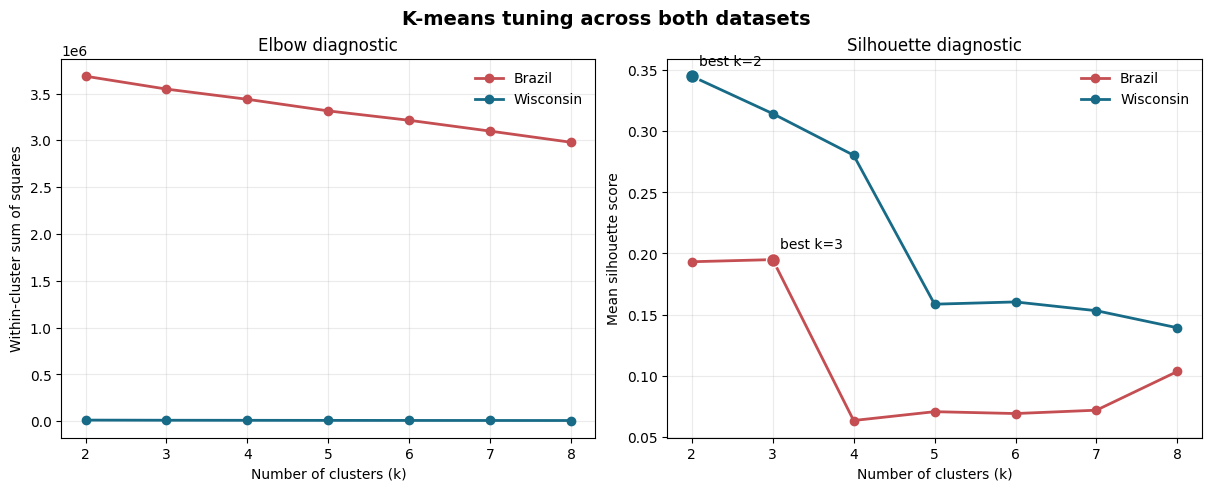

Brazil: selected k=3, silhouette=0.195, inertia=3,547,194.4
Wisconsin: selected k=2, silhouette=0.345, inertia=11,595.5


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)
colors = {"Wisconsin": "#176b87", "Brazil": "#c44e52"}
for dataset, group in tuning_results.groupby("dataset"):
    axes[0].plot(group.k, group.inertia, marker="o", linewidth=2, label=dataset, color=colors[dataset])
    axes[1].plot(group.k, group.silhouette, marker="o", linewidth=2, label=dataset, color=colors[dataset])
    best = group.loc[group.silhouette.idxmax()]
    axes[1].scatter(best.k, best.silhouette, s=100, color=colors[dataset], edgecolor="white", zorder=4)
    axes[1].annotate(f"best k={int(best.k)}", (best.k, best.silhouette), xytext=(5, 8), textcoords="offset points")
axes[0].set(title="Elbow diagnostic", xlabel="Number of clusters (k)", ylabel="Within-cluster sum of squares")
axes[1].set(title="Silhouette diagnostic", xlabel="Number of clusters (k)", ylabel="Mean silhouette score")
for ax in axes:
    ax.set_xticks(list(K_VALUES))
    ax.grid(alpha=.25)
    ax.legend(frameon=False)
fig.suptitle("K-means tuning across both datasets", fontsize=14, fontweight="bold")
fig.savefig(FIGURE_DIR / "week10_kmeans_tuning.png", dpi=300, bbox_inches="tight")
plt.show()

for dataset, group in tuning_results.groupby("dataset"):
    best = group.loc[group.silhouette.idxmax()]
    print(f"{dataset}: selected k={int(best.k)}, silhouette={best.silhouette:.3f}, inertia={best.inertia:,.1f}")

## 4. Final clusters and stability

I use the silhouette-selected k for the remaining analysis. K-means can be sensitive to its random starting centroids, so I refit the selected solution with five different random seeds and compare assignments using adjusted Rand index (ARI). High ARI indicates that the grouping is reproducible despite label permutation.

In [6]:
final_w = wisconsin_models[wisconsin_best_k]
final_b = brazil_models[brazil_best_k]
labels_w, labels_b = final_w.labels_, final_b.labels_

def stability_table(X, k, dataset):
    reference = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE).fit_predict(X)
    rows = []
    for seed in [0, 1, 2, 3, 4]:
        candidate = KMeans(n_clusters=k, n_init=20, random_state=seed).fit_predict(X)
        rows.append({
            "dataset": dataset,
            "seed": seed,
            "k": k,
            "ARI_vs_seed_42": adjusted_rand_score(reference, candidate),
        })
    return pd.DataFrame(rows)

stability_results = pd.concat([
    stability_table(X_w, wisconsin_best_k, "Wisconsin"),
    stability_table(X_b, brazil_best_k, "Brazil"),
], ignore_index=True)
display(stability_results.round(3))
display(stability_results.groupby("dataset")["ARI_vs_seed_42"].agg(["mean", "min", "max"]).round(3))

,dataset,seed,k,ARI_vs_seed_42
0,Wisconsin,0,2,1.000
1,Wisconsin,1,2,1.000
2,Wisconsin,2,2,1.000
3,Wisconsin,3,2,0.965
4,Wisconsin,4,2,1.000
5,Brazil,0,3,0.062
6,Brazil,1,3,0.022
7,Brazil,2,3,0.995
8,Brazil,3,3,0.641
9,Brazil,4,3,0.398


,mean,min,max
dataset,,,
Brazil,0.424,0.022,0.995
Wisconsin,0.993,0.965,1.000


The repeated-start ARI is the k-means analogue of a stability/overfitting check. n_init=20 reduces dependence on one unlucky initialization, while repeated seeds reveal whether the selected solution is intrinsically unstable. This does not prove generalization to a new population; an additional sample or external validation would be needed.

## 5. PCA visualization

PCA is used only to display the high-dimensional assignments in two dimensions. The clusters were fit in the full standardized feature spaces, so visual overlap in the PCA plot does not necessarily mean the original clusters overlap in every direction.

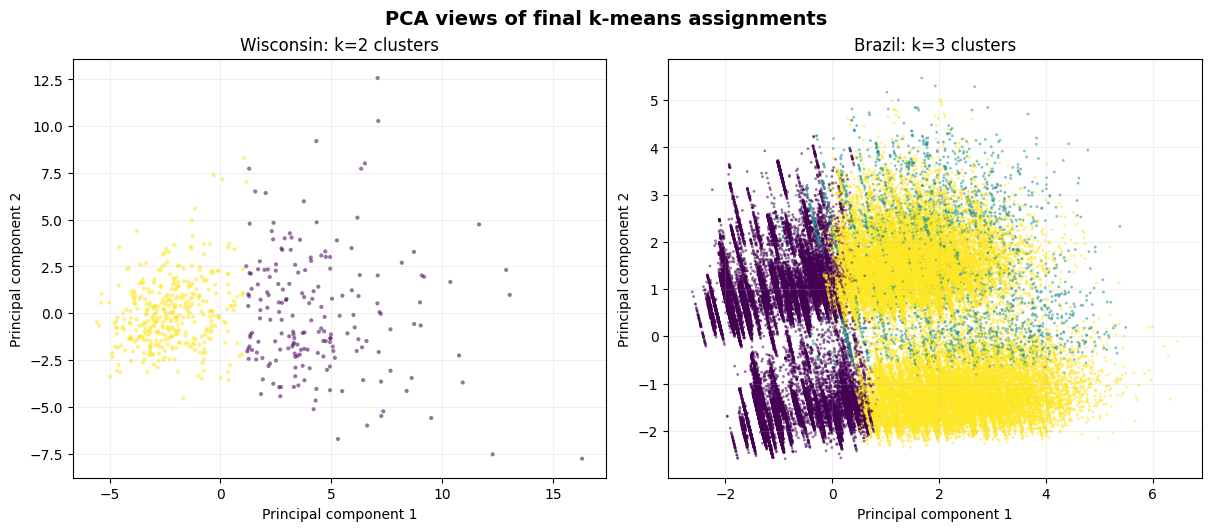

In [7]:
pca_w = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_w)
pca_b = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_b)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), constrained_layout=True)
for ax, coordinates, labels, dataset, k in [
    (axes[0], pca_w, labels_w, "Wisconsin", wisconsin_best_k),
    (axes[1], pca_b, labels_b, "Brazil", brazil_best_k),
]:
    ax.scatter(
        coordinates[:, 0], coordinates[:, 1], c=labels,
        cmap="viridis", s=9 if dataset == "Wisconsin" else 4,
        alpha=.55, linewidths=0,
    )
    ax.set(title=f"{dataset}: k={k} clusters", xlabel="Principal component 1", ylabel="Principal component 2")
    ax.grid(alpha=.18)
fig.suptitle("PCA views of final k-means assignments", fontsize=14, fontweight="bold")
fig.savefig(FIGURE_DIR / "week10_kmeans_pca_clusters.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Interpret clusters using the known outcome

The outcome is added back only now. This table does not measure predictive accuracy: it asks whether unsupervised groups have different observed diagnosis/outcome rates. Cluster-level differences are useful for generating hypotheses, but they should not be described as causal or as validated risk strata.

,dataset,k,cluster,n,outcome_rate
0,Wisconsin,2,0,189,0.926
1,Wisconsin,2,1,380,0.097
2,Brazil,3,0,61328,0.007
3,Brazil,3,1,2924,0.166
4,Brazil,3,2,35748,0.171


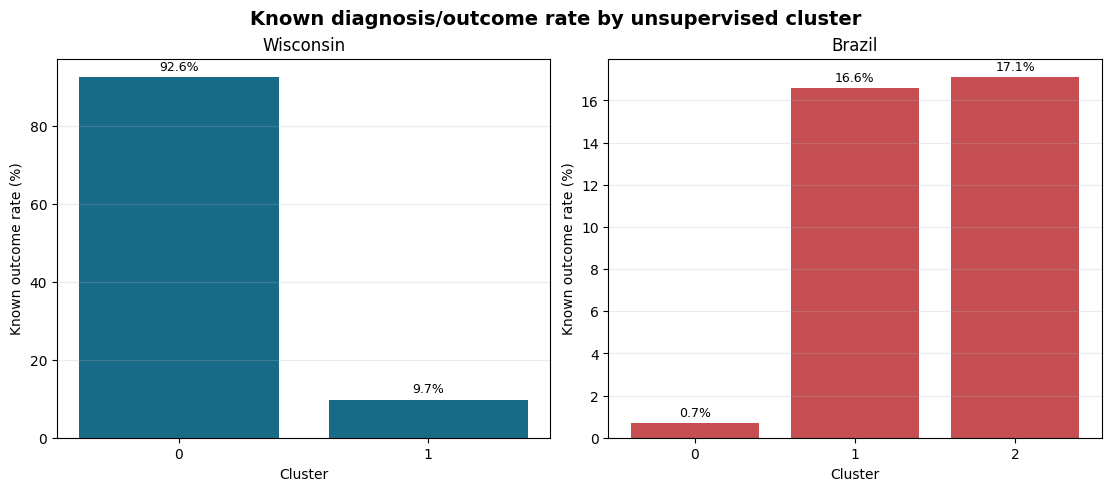

In [8]:
def cluster_outcome_profile(labels, y, dataset, k):
    profile = pd.DataFrame({"cluster": labels, "outcome": np.asarray(y)})
    result = profile.groupby("cluster", as_index=False).agg(
        n=("outcome", "size"),
        outcome_rate=("outcome", "mean"),
    )
    result.insert(0, "dataset", dataset)
    result.insert(1, "k", k)
    return result

cluster_profiles = pd.concat([
    cluster_outcome_profile(labels_w, wisconsin_df[wisconsin_target], "Wisconsin", wisconsin_best_k),
    cluster_outcome_profile(labels_b, brazil_df[brazil_target], "Brazil", brazil_best_k),
], ignore_index=True)
display(cluster_profiles.assign(outcome_rate=lambda d: d.outcome_rate.round(3)))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), constrained_layout=True)
for ax, dataset, color in zip(axes, ["Wisconsin", "Brazil"], ["#176b87", "#c44e52"]):
    data = cluster_profiles[cluster_profiles.dataset == dataset]
    bars = ax.bar(data.cluster.astype(str), data.outcome_rate * 100, color=color)
    ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=9)
    ax.set(title=dataset, xlabel="Cluster", ylabel="Known outcome rate (%)")
    ax.grid(axis="y", alpha=.25)
fig.suptitle("Known diagnosis/outcome rate by unsupervised cluster", fontsize=14, fontweight="bold")
fig.savefig(FIGURE_DIR / "week10_kmeans_outcome_profiles.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Sensitivity to scaling and feature representation

Distance-based clustering depends on geometry. I compare the standardized full-feature solution with narrower representations. Wisconsin's reduced representation uses the ten mean measurement variables. Brazil's reduced representation excludes age, profession code, and morphology code, testing how much the coded variables drive the groups. Silhouette should be considered together with ARI versus the full-feature assignments.

In [9]:
def sensitivity_row(df, target, dataset, k, variant, columns=None, scaled=True, reference=None):
    X_variant, _ = prepare_for_kmeans(df, target, scaled=scaled, columns=columns)
    model = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE).fit(X_variant)
    row = {
        "dataset": dataset,
        "variant": variant,
        "silhouette": silhouette_score(
            X_variant, model.labels_, sample_size=min(10_000, len(X_variant)), random_state=RANDOM_STATE
        ),
    }
    if reference is not None:
        row["ARI_vs_full"] = adjusted_rand_score(reference, model.labels_)
    return row

w_reduced = [c for c in wisconsin_df.columns if c.endswith("1") and c != wisconsin_target]
b_reduced = [c for c in brazil_df.columns if c not in [brazil_target, "Age", "Code.Profession", "Code.of.Morphology"]]
sensitivity_results = pd.DataFrame([
    sensitivity_row(wisconsin_df, wisconsin_target, "Wisconsin", wisconsin_best_k, "full standardized", scaled=True, reference=labels_w),
    sensitivity_row(wisconsin_df, wisconsin_target, "Wisconsin", wisconsin_best_k, "mean measurements standardized", columns=w_reduced, scaled=True, reference=labels_w),
    sensitivity_row(brazil_df, brazil_target, "Brazil", brazil_best_k, "full standardized", scaled=True, reference=labels_b),
    sensitivity_row(brazil_df, brazil_target, "Brazil", brazil_best_k, "clinical/demographic standardized", columns=b_reduced, scaled=True, reference=labels_b),
    sensitivity_row(wisconsin_df, wisconsin_target, "Wisconsin", wisconsin_best_k, "full unscaled", scaled=False, reference=labels_w),
    sensitivity_row(brazil_df, brazil_target, "Brazil", brazil_best_k, "full unscaled", scaled=False, reference=labels_b),
])
display(sensitivity_results.round(3))

,dataset,variant,silhouette,ARI_vs_full
0,Wisconsin,full standardized,0.345,1.000
1,Wisconsin,mean measurements standardized,0.395,0.848
2,Brazil,full standardized,0.195,1.000
3,Brazil,clinical/demographic standardized,0.195,1.000
4,Wisconsin,full unscaled,0.697,0.521
5,Brazil,full unscaled,0.796,0.050


## Milestone 2 interpretation draft

K-means provides an unsupervised contrast between the datasets. Wisconsin's continuous tumor measurements are naturally suited to standardized Euclidean geometry, while Brazil combines sparse indicators, missingness, and coded registry variables. Therefore, Brazil's result should be interpreted more cautiously: cluster quality and stability may reflect the chosen representation as much as naturally occurring patient subgroups.

The strongest evidence for a substantive interpretation is convergence across the silhouette result, repeated-start stability, sensitivity analysis, PCA display, and outcome profiles. If these disagree, the disagreement is itself important and should be reported as a limitation. A cluster with a different outcome rate is a hypothesis-generating subgroup, not proof of a clinical mechanism or a replacement for supervised validation.

For the breadth section, summarize the setup, selected k, silhouette score, stability, and key cluster interpretation for both datasets. For the depth section, expand the geometry of scaling, walk through the k-selection evidence, explain the sensitivity results, and connect the outcome profiles to the project's research question without claiming causation.

## AI-use note for the eventual appendix

AI assistance was used to help organize the Week 10 notebook workflow, identify Milestone 2 rubric requirements, draft analysis-cell language, and suggest diagnostic comparisons. All data loading, model fitting, metrics, plots, and interpretations should be reviewed and verified by the student before submission.